In [1]:
from geomloss import SamplesLoss
import torch
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

DATAFILE = "/home/gokulg/orcd/scratch/lt/data/kl0.0_d50_l2_covnocov_adata_with_embeddings.h5ad"
TYPES_TO_REMOVE = ["doublet"]

adata = sc.read_h5ad(DATAFILE)

adata = adata[~adata.obs["annotation"].isin(TYPES_TO_REMOVE)].copy()

obsm_key = "X_scvi"
batch_size = 512
n_batches = 50


/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


within-embryo:   0%|          | 0/16 [00:00<?, ?it/s]

pairwise:   0%|          | 0/120 [00:00<?, ?it/s]

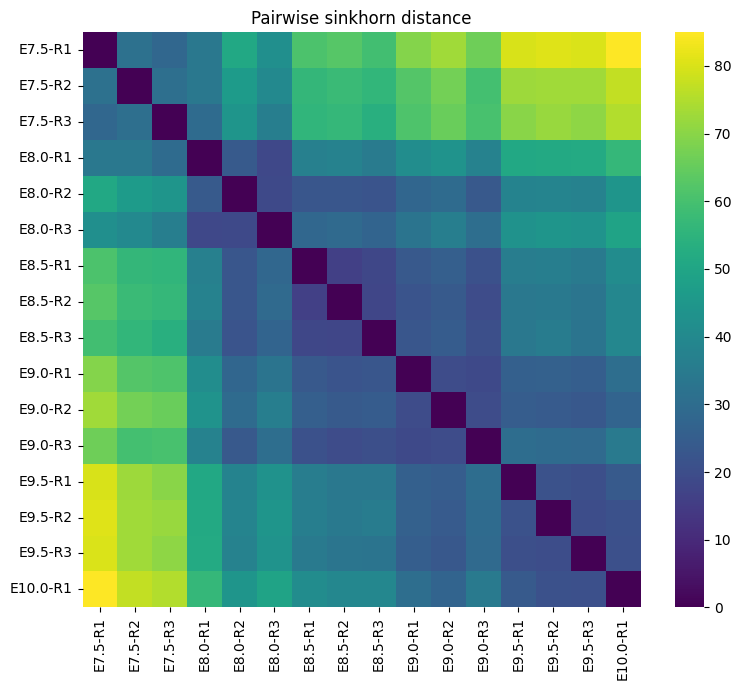

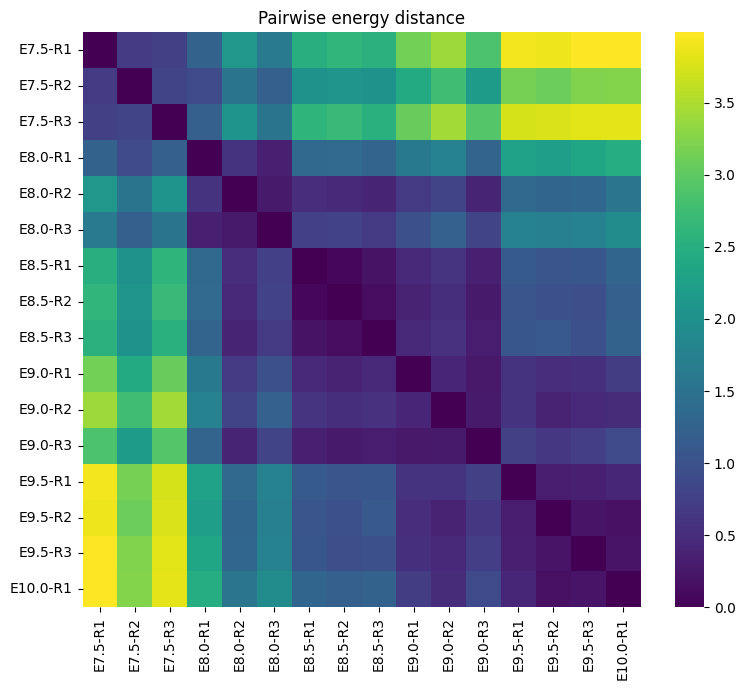

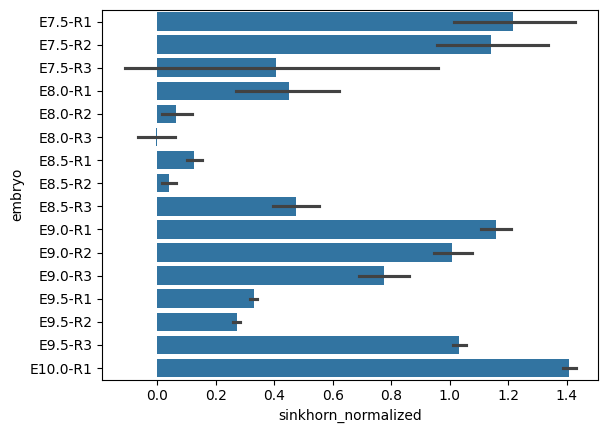

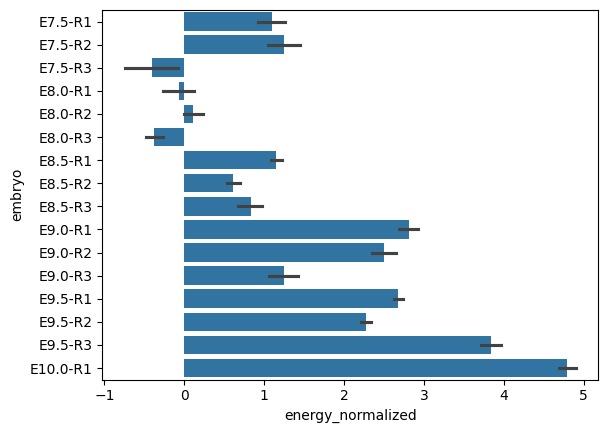

In [2]:
from itertools import combinations

metrics = {
    "sinkhorn": SamplesLoss("sinkhorn", p=2, blur=0.05),
    "energy": SamplesLoss("energy", p=2),
}

# ---- pre-extract cells per embryo ----
embryo_ids = adata.obs["embryo"].unique()
embryo_host = {}
embryo_donor = {}
embryo_all = {}

for embryo in embryo_ids:
    mask_host = (adata.obs["embryo"] == embryo) & (adata.obs["type"] == "host")
    mask_donor = (adata.obs["embryo"] == embryo) & (adata.obs["type"] == "donor")
    host_cells = torch.tensor(adata[mask_host].obsm[obsm_key], dtype=torch.float32)
    donor_cells = torch.tensor(adata[mask_donor].obsm[obsm_key], dtype=torch.float32)
    embryo_host[embryo] = host_cells
    embryo_donor[embryo] = donor_cells
    embryo_all[embryo] = torch.cat([host_cells, donor_cells], dim=0)

# ---- within-embryo: donor vs host ----
within_records = []
for embryo in tqdm(embryo_ids, desc="within-embryo"):
    host_cells = embryo_host[embryo]
    donor_cells = embryo_donor[embryo]
    n_host = host_cells.shape[0]
    n_donor = donor_cells.shape[0]

    if n_donor == 0 or n_host == 0:
        continue

    # ---- random disjoint partitioning ----
    # host: 2 partitions per batch (one for test, one for baseline)
    # donor: 1 partition per batch
    # cap batches so every partition has at least 1 cell
    eff_batches = min(n_batches, n_host // 2, n_donor)
    if eff_batches == 0:
        continue

    host_perm = torch.randperm(n_host)
    donor_perm = torch.randperm(n_donor)
    host_parts = torch.tensor_split(host_perm, 2 * eff_batches)
    donor_parts = torch.tensor_split(donor_perm, eff_batches)

    for batch_idx in range(eff_batches):
        h1_pool = host_cells[host_parts[2 * batch_idx]]
        h2_pool = host_cells[host_parts[2 * batch_idx + 1]]
        d_pool = donor_cells[donor_parts[batch_idx]]

        # iid subsample (with replacement) from each partition
        h1 = h1_pool[torch.randint(h1_pool.shape[0], (batch_size,))]
        h2 = h2_pool[torch.randint(h2_pool.shape[0], (batch_size,))]
        d = d_pool[torch.randint(d_pool.shape[0], (batch_size,))]

        row = {
            "embryo": embryo,
            "batch": batch_idx,
            "n_donor": n_donor,
            "n_host": n_host,
            "n_host_partition": h1_pool.shape[0],
            "n_donor_partition": d_pool.shape[0],
        }
        for name, metric in metrics.items():
            row[name] = metric(h1, d).item()
        for name, metric in metrics.items():
            row[f"{name}_baseline"] = metric(h1, h2).item()
        within_records.append(row)

df_within = pd.DataFrame(within_records)
for name in metrics:
    df_within[f"{name}_normalized"] = np.log2(df_within[name] / df_within[f"{name}_baseline"])

# ---- pairwise: all embryo pairs (upper triangle only) ----
pairwise_records = []
embryo_list = list(embryo_ids)

for i, j in tqdm(list(combinations(range(len(embryo_list)), 2)), desc="pairwise"):
    emb_a, emb_b = embryo_list[i], embryo_list[j]
    cells_a = embryo_all[emb_a]
    cells_b = embryo_all[emb_b]
    n_a = cells_a.shape[0]
    n_b = cells_b.shape[0]

    if n_a == 0 or n_b == 0:
        continue

    eff_batches = min(n_batches, n_a, n_b)
    if eff_batches == 0:
        continue

    perm_a = torch.randperm(n_a)
    perm_b = torch.randperm(n_b)
    parts_a = torch.tensor_split(perm_a, eff_batches)
    parts_b = torch.tensor_split(perm_b, eff_batches)

    for batch_idx in range(eff_batches):
        pool_a = cells_a[parts_a[batch_idx]]
        pool_b = cells_b[parts_b[batch_idx]]

        # iid subsample (with replacement) from each partition
        sa = pool_a[torch.randint(pool_a.shape[0], (batch_size,))]
        sb = pool_b[torch.randint(pool_b.shape[0], (batch_size,))]

        row = {
            "embryo_a": emb_a,
            "embryo_b": emb_b,
            "batch": batch_idx,
            "n_a": n_a,
            "n_b": n_b,
        }
        for name, metric in metrics.items():
            row[name] = metric(sa, sb).item()
        pairwise_records.append(row)

df_pairwise = pd.DataFrame(pairwise_records)

# ---- pivot to symmetric matrix for heatmapping ----
def to_symmetric_matrix(df_pw, value_col, embryo_order):
    """Aggregate batches to mean, then fill both triangles."""
    agg = df_pw.groupby(["embryo_a", "embryo_b"])[value_col].mean()
    n = len(embryo_order)
    idx = {e: k for k, e in enumerate(embryo_order)}
    mat = pd.DataFrame(np.nan, index=embryo_order, columns=embryo_order)
    for (a, b), v in agg.items():
        mat.iloc[idx[a], idx[b]] = v
        mat.iloc[idx[b], idx[a]] = v
    np.fill_diagonal(mat.values, 0.0)
    return mat

for name in metrics:
    mat = to_symmetric_matrix(df_pairwise, name, embryo_list)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(mat.astype(float), annot=False, ax=ax, cmap="viridis")
    ax.set_title(f"Pairwise {name} distance")
    plt.tight_layout()
    plt.show()

sns.barplot(data=df_within, y="embryo", x="sinkhorn_normalized")
plt.show()
sns.barplot(data=df_within, y="embryo", x="energy_normalized")
plt.show()

In [3]:
# save dataframes
df_within.to_csv("host_donor_distributional_distances.csv", index=False)
df_pairwise.to_csv("pairwise_embryo_distributional_distances.csv", index=False)